Saving Internet Users in Kenya.xlsx to Internet Users in Kenya.xlsx


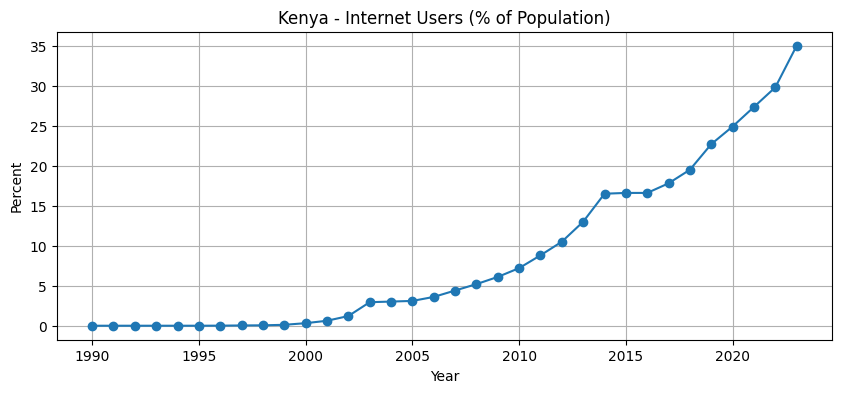

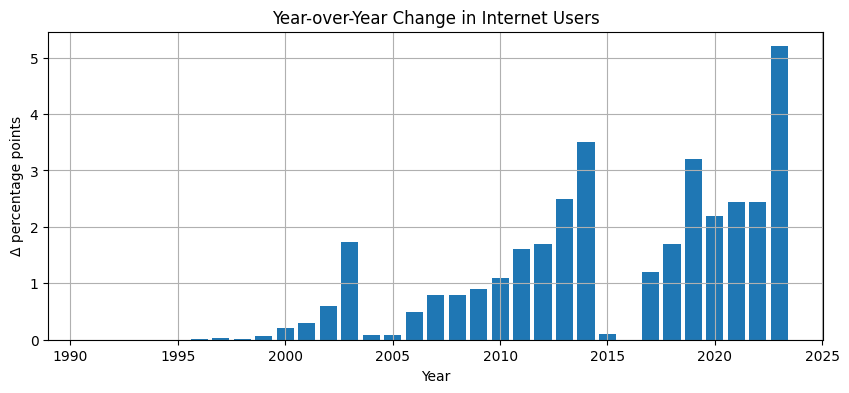

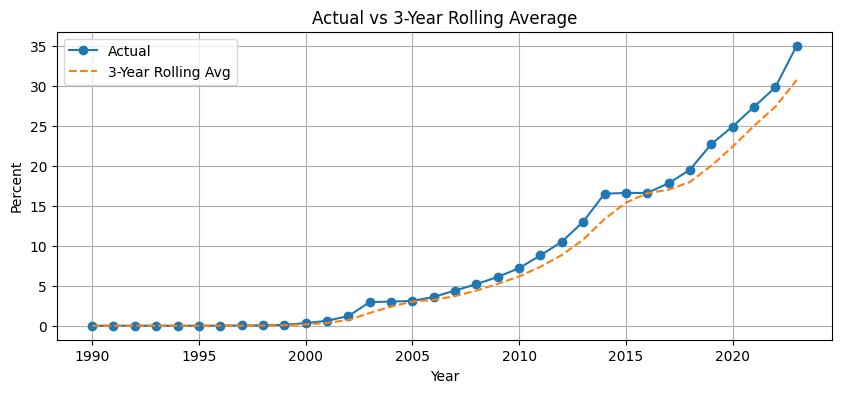

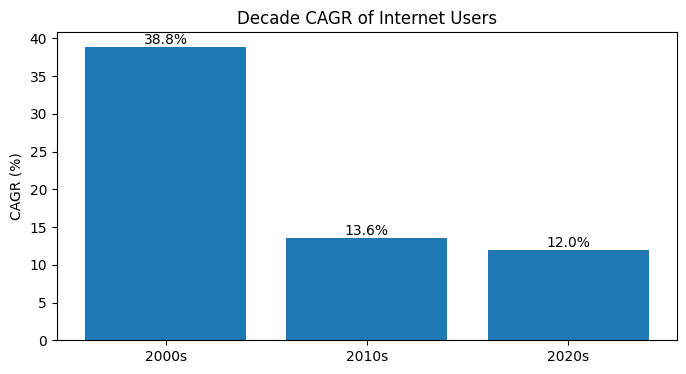

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# Upload & Read Excel/CSV
uploaded = files.upload()
fname = list(uploaded.keys())[0]
df = pd.read_excel("Internet Users in Kenya.xlsx")

# Clean & Prepare
df.columns = [c.strip().lower() for c in df.columns]
df['observation_date'] = pd.to_datetime(df['observation_date'], errors='coerce')
df['itnetuserp2ken'] = pd.to_numeric(df['itnetuserp2ken'], errors='coerce')
df = df.dropna().sort_values('observation_date')
df['year'] = df['observation_date'].dt.year

# 1) Line Chart
plt.figure(figsize=(10,4))
plt.plot(df['year'], df['itnetuserp2ken'], marker='o')
plt.title('Kenya - Internet Users (% of Population)')
plt.xlabel('Year')
plt.ylabel('Percent')
plt.grid(True)
plt.show()

# 2) YoY Change
df['yoy_change'] = df['itnetuserp2ken'].diff()
plt.figure(figsize=(10,4))
plt.bar(df['year'], df['yoy_change'])
plt.title('Year-over-Year Change in Internet Users')
plt.xlabel('Year')
plt.ylabel('Δ percentage points')
plt.grid(True)
plt.show()

# 3) Actual vs 3-Year Rolling Avg
df['roll3'] = df['itnetuserp2ken'].rolling(3, min_periods=1).mean()
plt.figure(figsize=(10,4))
plt.plot(df['year'], df['itnetuserp2ken'], marker='o', label='Actual')
plt.plot(df['year'], df['roll3'], linestyle='--', label='3-Year Rolling Avg')
plt.title('Actual vs 3-Year Rolling Average')
plt.xlabel('Year')
plt.ylabel('Percent')
plt.legend()
plt.grid(True)
plt.show()

# 4) Decade CAGR
def cagr(start, end, years):
    if start <= 0 or years <= 0:
        return np.nan
    return (end/start)**(1/years) - 1

decades = []
for start_dec in [1990, 2000, 2010, 2020]:
    sub = df[(df['year']>=start_dec) & (df['year']<start_dec+10)]
    if not sub.empty:
        first = sub.iloc[0]['itnetuserp2ken']
        last = sub.iloc[-1]['itnetuserp2ken']
        yrs = sub.iloc[-1]['year'] - sub.iloc[0]['year']
        decades.append({'Decade': f'{start_dec}s', 'CAGR_%': cagr(first, last, yrs)*100})

dec_df = pd.DataFrame(decades)
plt.figure(figsize=(8,4))
plt.bar(dec_df['Decade'], dec_df['CAGR_%'])
plt.title('Decade CAGR of Internet Users')
plt.ylabel('CAGR (%)')
for i, v in enumerate(dec_df['CAGR_%']):
    plt.text(i, v, f'{v:.1f}%', ha='center', va='bottom')
plt.show()
